# C3M1: Peer Reviewed Assignment

### Outline:
The objectives for this assignment:

1. Apply Binomial regression methods to real data.
2. Understand how to analyze and interpret binomial regression models.
3. Flex our math skills by determining whether certain distributions are members of the exponential family.

General tips:

1. Read the questions carefully to understand what is being asked.
2. This work will be reviewed by another human, so make sure that you are clear and concise in what your explanations and answers.

In [2]:
# Load required libraries
library(tidyverse)
library(dplyr)

## Problem 1: Binomial (Logistic) Regression

The National Institute of Diabetes and Digestive and Kidney Diseases conducted a study of 768 adult female Pima Indians living near Phoenix, AZ. The purpose of the study was to investigate the factors related to diabetes. 

*Before we analyze these data, we should note that some have raised ethical issues with its collection and popularity in the statistics and data science community. We should think seriously about these concerns. For example, Maya Iskandarani wrote a brief [piece](https://researchblog.duke.edu/2016/10/24/diabetes-and-privacy-meet-big-data/) on consent and privacy concerns raised by this dataset. After you familarize yourself with the data, we'll then turn to these ethical concerns.*


First, we'll use these data to get some practice with GLM and Logistic regression.

In [74]:
# Load the data
pima = read.csv("pima.txt", sep="\t")
# Here's a description of the data: https://rdrr.io/cran/faraway/man/pima.html
head(pima)

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


### 1. (a) Data Cleaning? What about Data Scrubbing? Data Sterilizing?

This is a real data set, which means that there's likely going to be gaps and missing values in the data. Before doing any modeling, we should inspect the data and clean it if necesary.

Perform simple graphical and numerical summaries of the data. Pay attention for missing or nonsensical values. Can you find any obvious irregularities? If so, take appropriate steps to correct these problems. In the markdown cell, specify what cleaning you did and why you did it.

Finally, split your data into training and test sets. Let the training set contain $80\%$ of the rows and the test set contain the remaining $20\%$.

### Answer:

Let's start with numerical and graphical summary of the data. 

In [75]:
# Your Code Here
summary(pima)

    pregnant         glucose        diastolic         triceps     
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    insulin           bmi           diabetes           age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780   Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437   1st Qu.:24.00  
 Median : 30.5   Median :32.00   Median :0.3725   Median :29.00  
 Mean   : 79.8   Mean   :31.99   Mean   :0.4719   Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262   3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200   Max.   :81.00  
      test      
 Min.   :0.000  
 1st Qu.:0.000  
 Median :0.000  
 

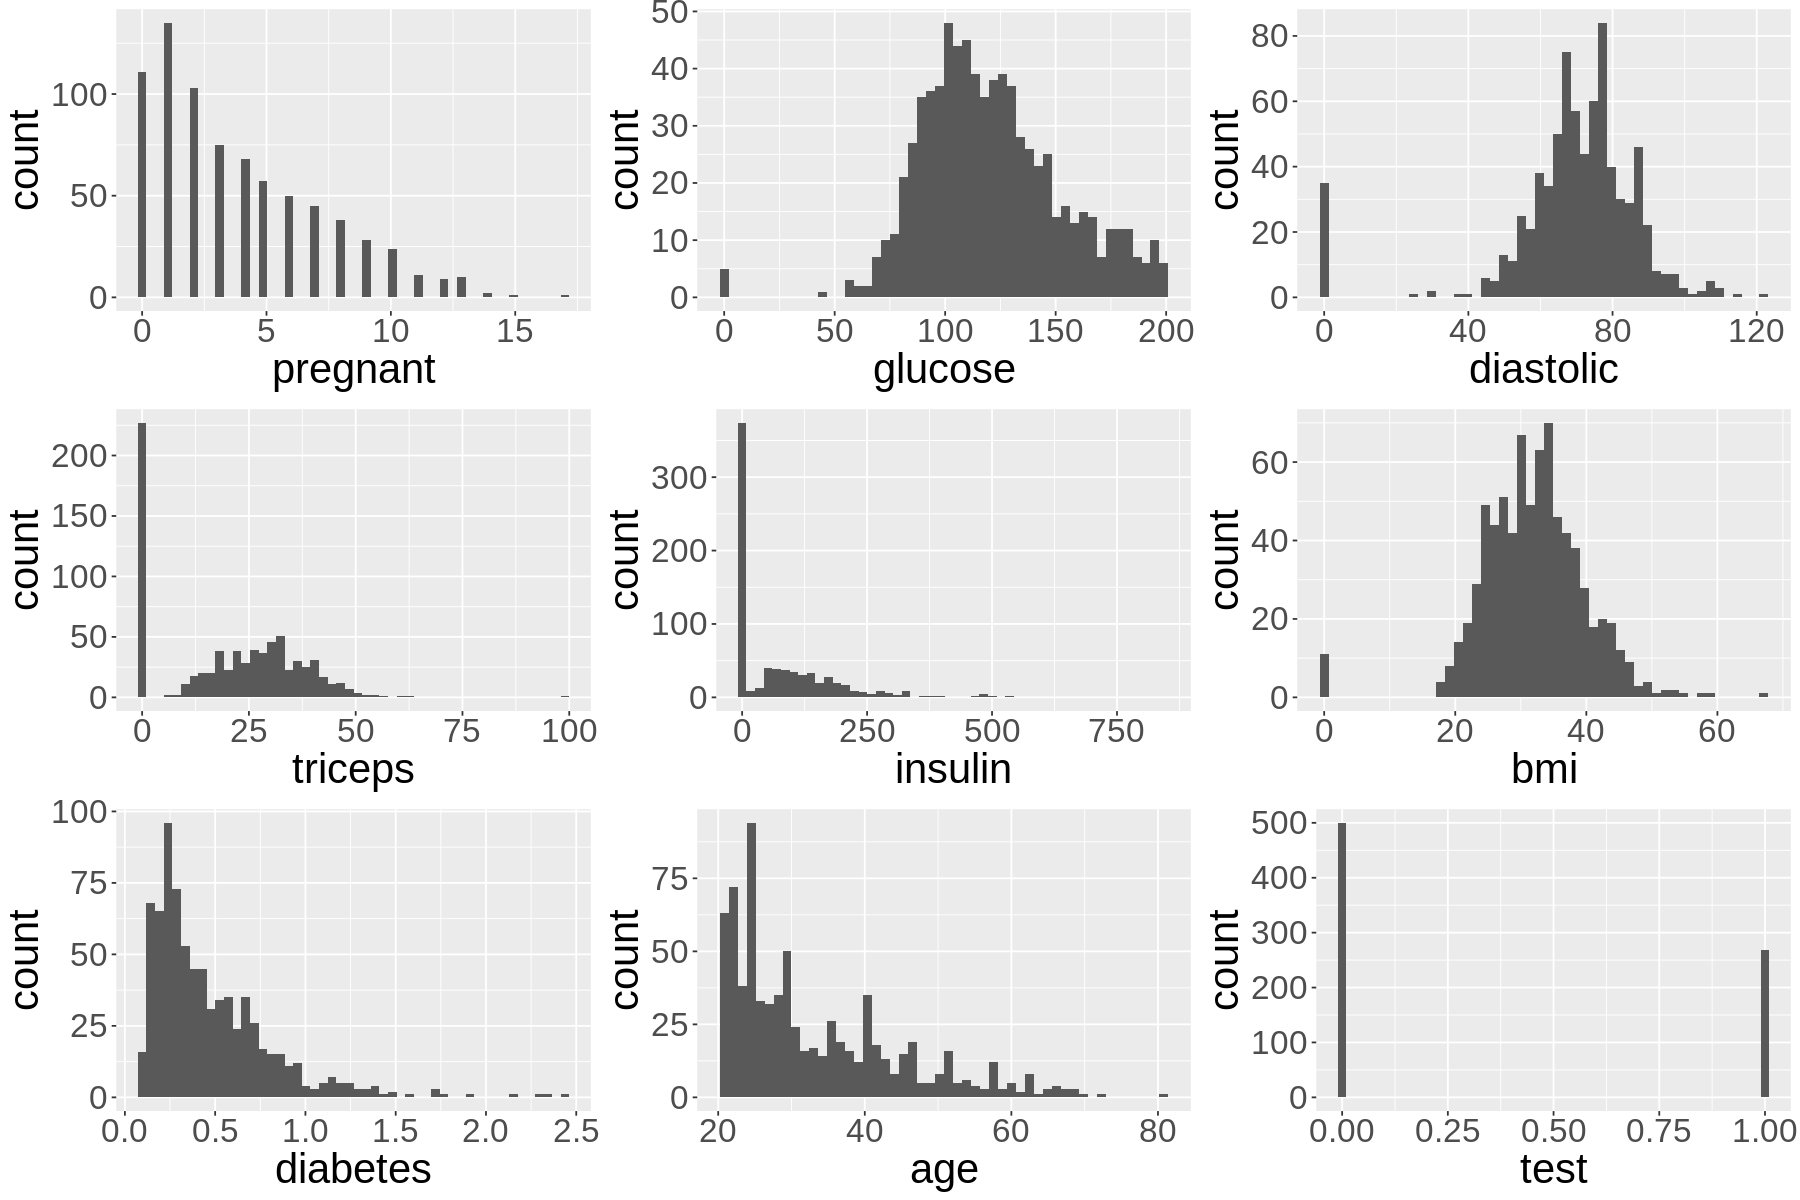

In [76]:
library(repr)
options(repr.plot.width=15, repr.plot.height=10)
library(ggplot2)
library(gridExtra)

plot.histogram <- function(pima) {
    vars <- names(pima)
    n <- length(vars)

    plist <- list()
    for (i in 1:n) {
        p <- ggplot(pima, aes_string(vars[i])) + 
             geom_histogram(bins=50) + xlab(vars[i]) +
             theme(text=element_text(size=25))
        plist <- c(plist, list(p))
    }
    return (do.call("grid.arrange", c(plist, ncol=3)))
}

plot.histogram(pima)

As can be seen from the above summary table and the histograms, 

* **obvious irregularities**: The predictor variables `gluscose`, `diastolic`, `triceps`, `insulin` and `bmi` have minimum values reported to be $0$, but the measurments corresponding to those variables are not likely to be zeros. Hence these values correspond to **missing** values for these variables. 
* **possible correction**: We shall replace the missing values with the **median** values of the corresponding variables, as done using the next code snippet.

    pregnant         glucose         diastolic         triceps     
 Min.   : 0.000   Min.   : 44.00   Min.   : 24.00   Min.   : 7.00  
 1st Qu.: 1.000   1st Qu.: 99.75   1st Qu.: 64.00   1st Qu.:25.00  
 Median : 3.000   Median :117.00   Median : 72.00   Median :29.00  
 Mean   : 3.845   Mean   :121.66   Mean   : 72.39   Mean   :29.11  
 3rd Qu.: 6.000   3rd Qu.:140.25   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.00   Max.   :122.00   Max.   :99.00  
    insulin           bmi           diabetes           age       
 Min.   : 14.0   Min.   :18.20   Min.   :0.0780   Min.   :21.00  
 1st Qu.:121.5   1st Qu.:27.50   1st Qu.:0.2437   1st Qu.:24.00  
 Median :125.0   Median :32.30   Median :0.3725   Median :29.00  
 Mean   :140.7   Mean   :32.46   Mean   :0.4719   Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262   3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200   Max.   :81.00  
      test      
 Min.   :0.000  
 1st Qu.:0.000  
 Median :0.

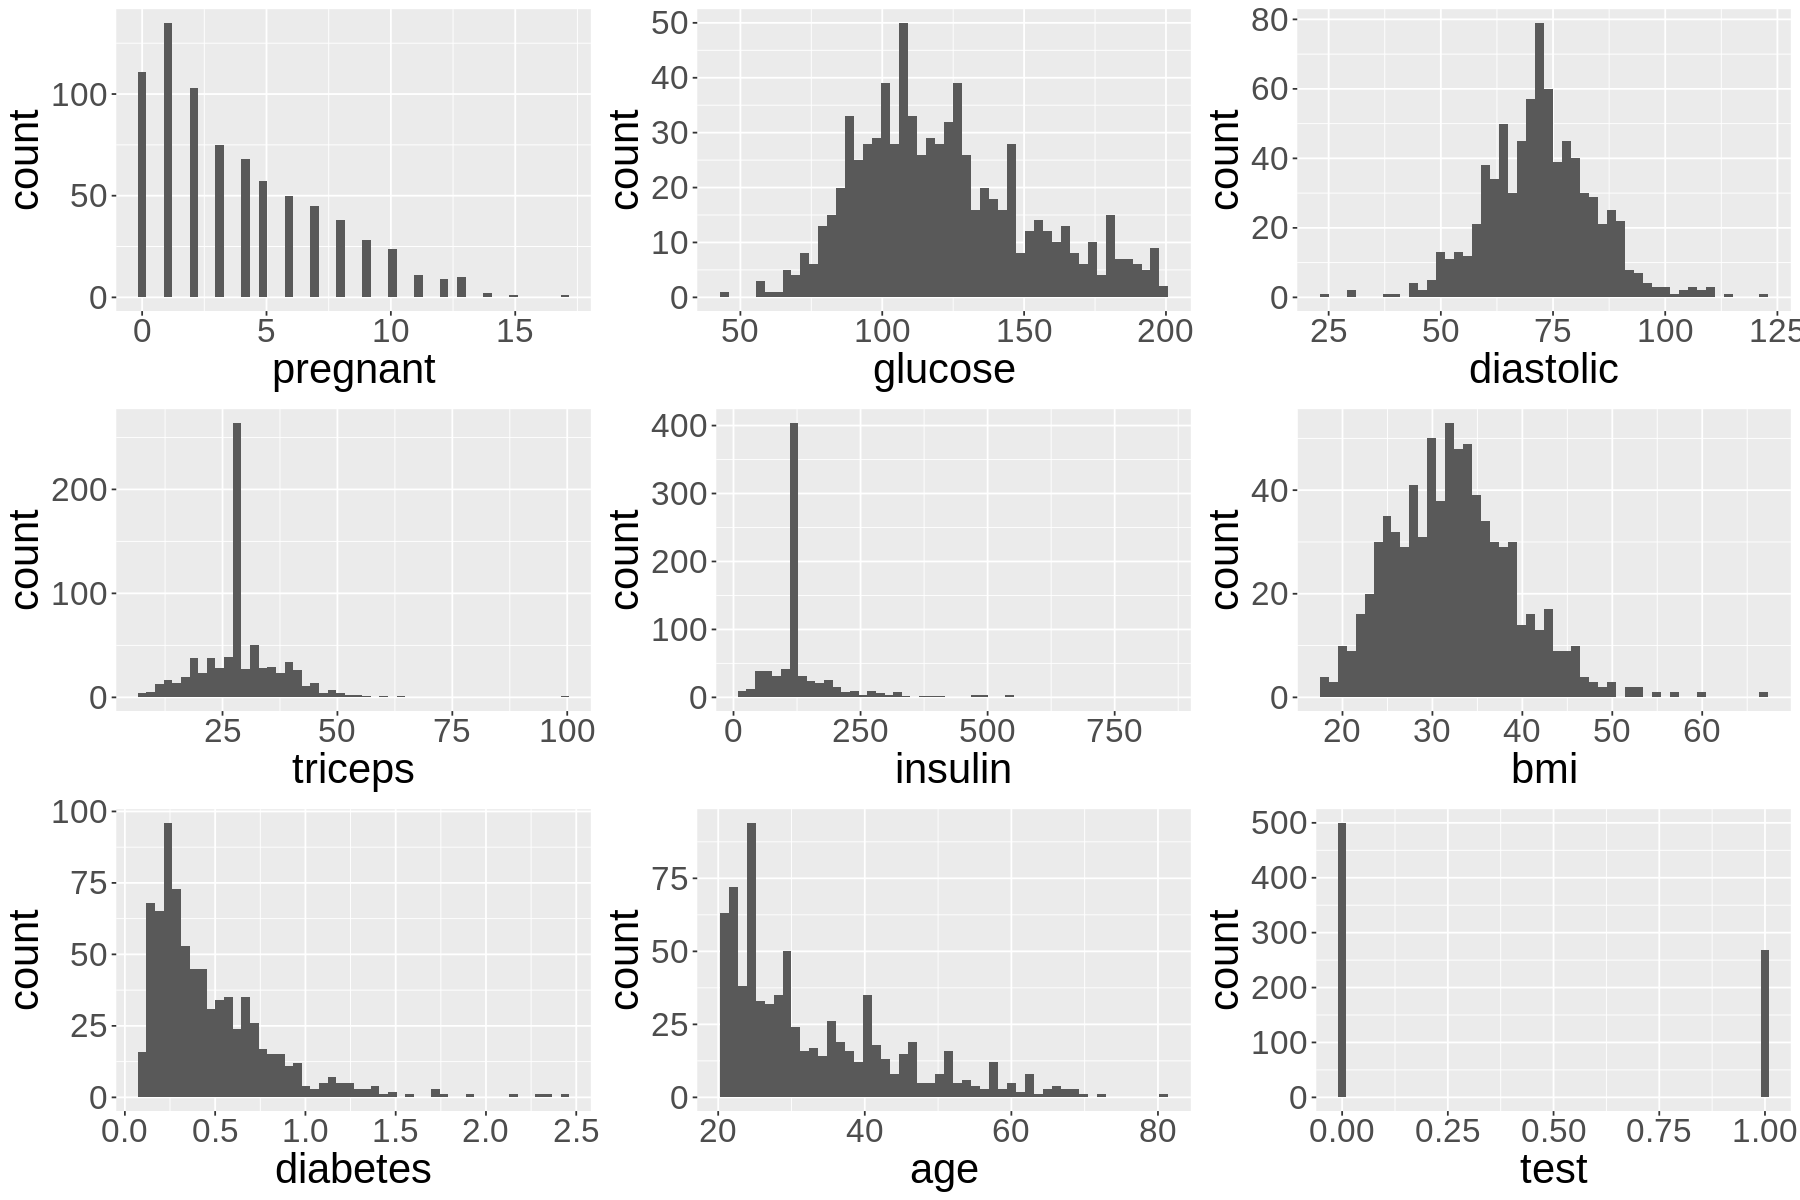

In [6]:
# replace missing zeros
for (var in c('glucose', 'diastolic', 'triceps', 'insulin', 'bmi')) {
    pima[pima[,var] == 0,var] = median(pima[pima[,var] != 0,var])
}
summary(pima)
options(repr.plot.width=15, repr.plot.height=10)
plot.histogram(pima) # plot histogram after replacing the missing values

The next plots show the association between the **predictor** variables with the **response** variable `test`.

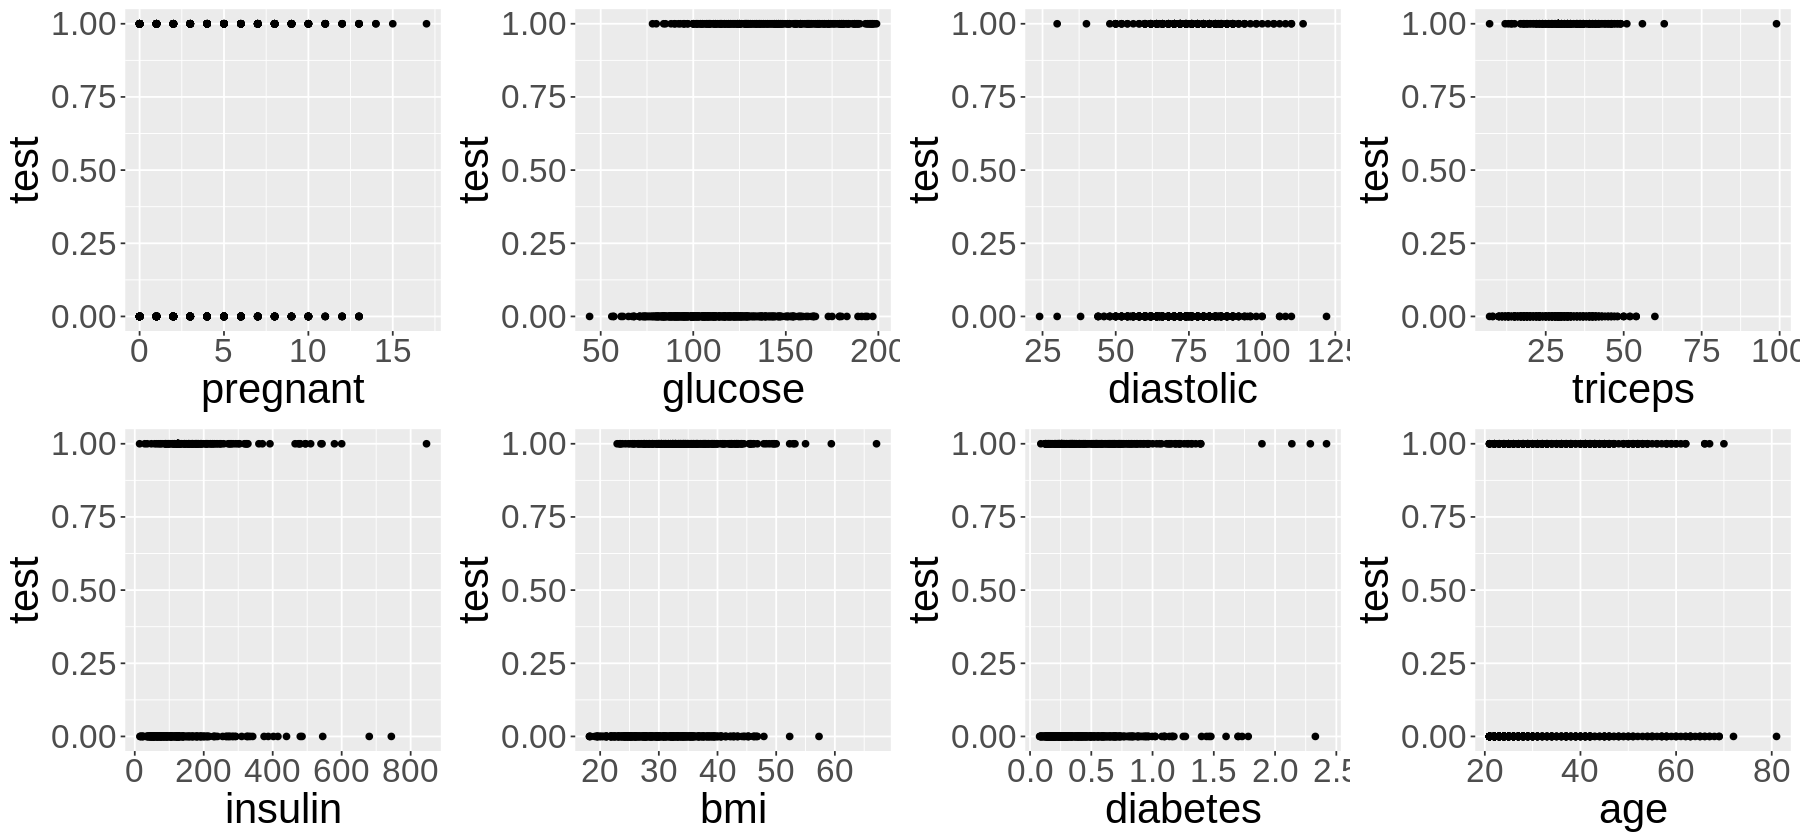

In [7]:
options(repr.plot.width=15, repr.plot.height=7)
vars <- names(pima)
n <- length(vars)
plist <- list()
for (i in 1:(n-1)) {
    p <- ggplot(pima, aes_string(vars[i], 'test')) + 
         geom_point() + xlab(vars[i]) + ylab('test') +
         theme(text=element_text(size=25))
    plist <- c(plist, list(p))
}
do.call("grid.arrange", c(plist, ncol=4))

Let's split the dataset into $80\%$ **train** and $20\%$ **test** dataset. A random seed needs to be used for reproducibility, as can be seen from the next code block.

In [8]:
set.seed(1771) #set the random number generator seed.
n = floor(0.8 * nrow(pima)) #find the number corresponding to 80% of the data
index = sample(seq_len(nrow(pima)), size = n) #randomly sample indicies to be included in the training set

train_pima = pima[index, ] #set the training set to be the randomly sampled rows of the dataframe
test_pima = pima[-index, ] #set the testing set to be the remaining rows
dim(test_pima) #check the dimensions
dim(train_pima) #check the dimensions
head(train_pima)

[1] 154   9

[1] 614   9

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>
103,0,125,96,29,125,22.5,0.262,21,0
398,0,131,66,40,125,34.3,0.196,22,1
491,2,83,65,28,66,36.8,0.629,24,0
64,2,141,58,34,128,25.4,0.699,24,0
177,6,85,78,29,125,31.2,0.382,42,0
519,13,76,60,29,125,32.8,0.180,41,0


### 1. (b) Initial GLM modelling


Our data is clean and we're ready to fit! What kind of model should we use to fit these data? Notice that the `test` variable is either $0$ or $1$, for whether the individual tested positive for diabetes. Because `test` is binary, we should use logistic regression (which is a kind of binomial regression).

Fit a model with `test` as the response and all the other variables as predictors. Can you tell whether this model fits the data?

### Answer:

Let's first fit the logistic regression model on the `train` dataset using the following code snippet.

In [9]:
# Your Code Here
glmod.pima <- glm(test ~ ., data = train_pima, family = 'binomial')
summary(glmod.pima)


Call:
glm(formula = test ~ ., family = "binomial", data = train_pima)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.8295  -0.7054  -0.3784   0.6926   2.4501  

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.7736714  0.9442738 -10.350  < 2e-16 ***
pregnant     0.1304058  0.0361369   3.609 0.000308 ***
glucose      0.0371852  0.0043977   8.456  < 2e-16 ***
diastolic   -0.0057042  0.0093674  -0.609 0.542561    
triceps      0.0003163  0.0145449   0.022 0.982651    
insulin     -0.0004574  0.0013531  -0.338 0.735348    
bmi          0.1029371  0.0206857   4.976 6.48e-07 ***
diabetes     1.0224173  0.3311137   3.088 0.002016 ** 
age          0.0154665  0.0108127   1.430 0.152603    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 795.19  on 613  degrees of freedom
Residual deviance: 559.13  on 605  degrees of freedom
AIC: 577.13

Num

As can be seen from the model summary above, the predictors `pregnant`, `glucose`, `bmi` and `diabetes` are statistically significant at $5\%$ level of significance. The next plot shows the predicted probability of the positive test against the value of the predictor variable glucose.

`geom_smooth()` using formula 'y ~ x'



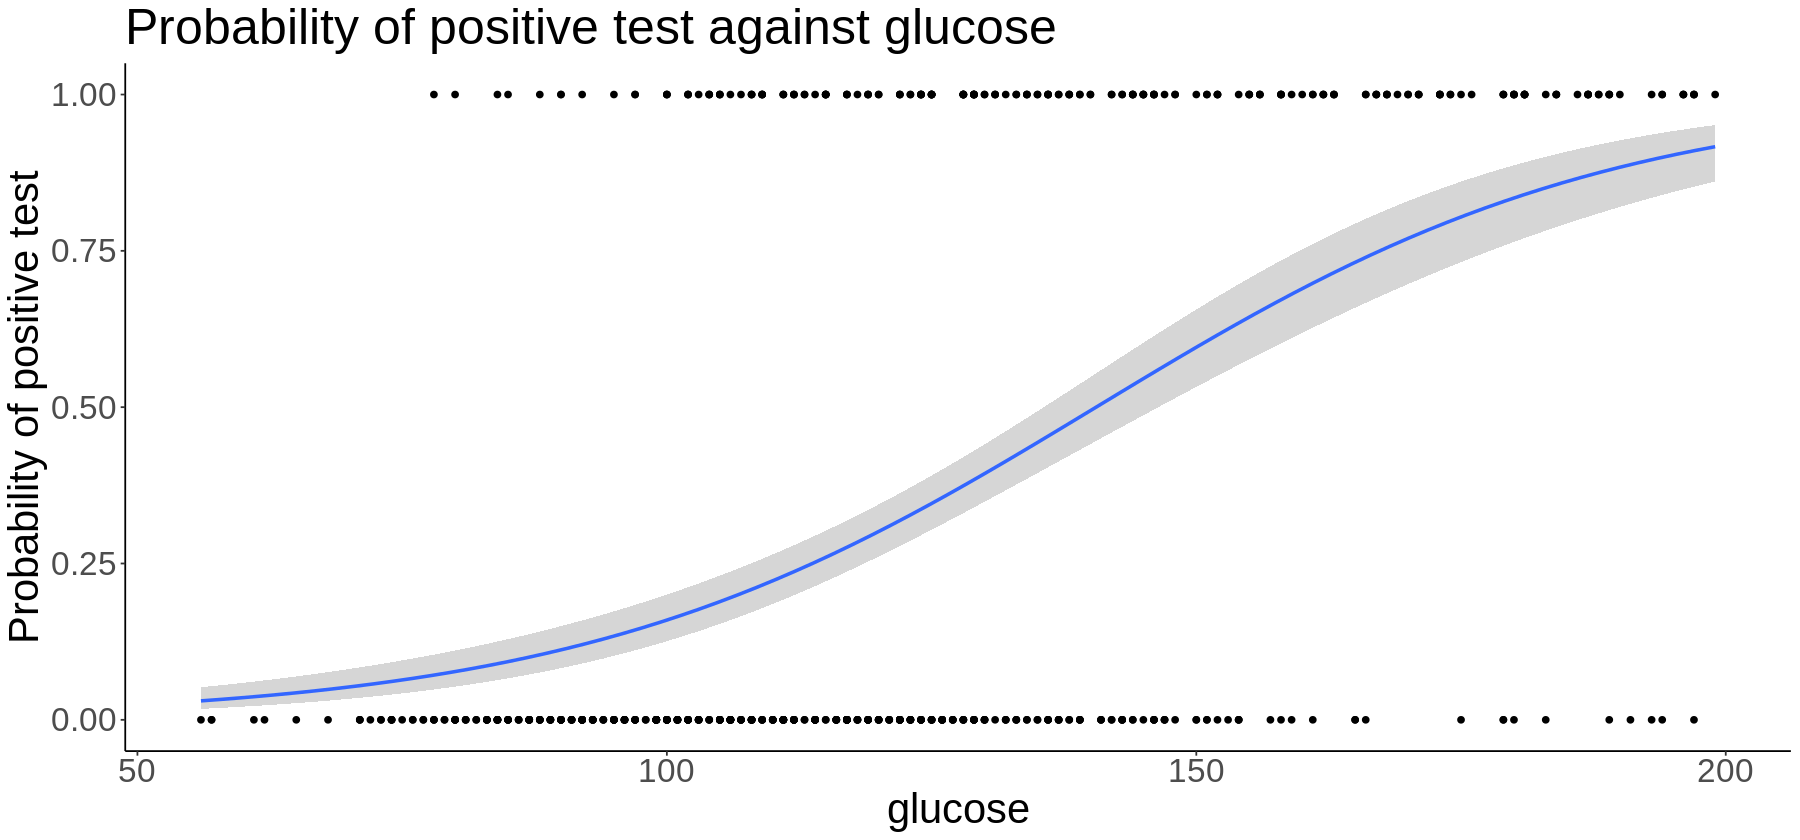

In [10]:
ggplot(glmod.pima, aes(x = glucose, y = test)) + geom_point() +
    stat_smooth(method = "glm", method.args = list(family=binomial), se = TRUE) + 
    xlab("glucose") +
    ylab("Probability of positive test") +
    ggtitle("Probability of positive test against glucose")+
    theme_classic()+
    theme(text=element_text(size=25))

#### Using common Pseudo R-Squared Measures to assess the model fit

Let's compute the `pseudo R-squared` for the model as 

$$\text{pseudo-R}^2 = \dfrac{\text{null deviance} - \text{residual deviance}}{\text{null deviance}}=1-\dfrac{\text{residual deviance}}{\text{null deviance}}$$

In [11]:
pseudo.r.squared <- with(summary(glmod.pima), 1 - deviance/null.deviance)
pseudo.r.squared

[1] 0.296857

Hence, the saturated (full) model explains $29.69\%$ of the variability in the data. 

Few common **Pseudo R-Squared** Measures are

* **McFadden's R²**: $$R^2_{McFadden}=1− \frac{text{log-likelihood of the null model}}{\text{log-likelihood of the fitted model}}$$

* **Cox & Snell R²**: $$R²_{\text{Cox & Snell}} = 1 - \left(\frac{\text{likelihood of the fitted model}}{\text{likelihood of the null model}}\right)^{\frac{2}{N}}$$

* **Nagelkerke R²**: $$R²_{\text{Nagelkerke}} = \frac{R²_{\text{Cox & Snell}}}{\text{Maximum value of } R²_{\text{Cox & Snell}}}$$

In [12]:
nullmod.pima <- glm(test ~ 1, data = train_pima, family = 'binomial')

logLik_null <- logLik(nullmod.pima)
logLik_fitted <- logLik(glmod.pima)

# McFadden's R²
R2 <- 1 - logLik_fitted / logLik_null
cat("mcFadden R2 = ", R2, "\n")

# Cox & Snell R²
R2 <- 1 - exp((2 / n) * (logLik_null - logLik_fitted))
cat("Cox & Snell R²:", R2, "\n")

# Nagelkerke R²
max_R2 <- 1 - exp((2 / n) * logLik_null)
R2 <- R2 / max_R2
cat("Nagelkerke R²:", R2, "\n")

mcFadden R2 =  0.296857 
Cox & Snell R²: 0.3191804 
Nagelkerke R²: 0.4395649 


Since **McFadden's R²** value in the range of $0.2$ to $0.4$ is considered a good fit for logistic regression, the model can be considered to be a good fit.

#### Accessing model fit by using model Accuracy on held-out dataset

As can be seen from below, the accuracy of prediction by the model on the test dataset is around $76\%$ and precision, recall metrics are not that bad, hence the model can be considered to be a good fit.

In [13]:
test_pred <- as.integer(predict(glmod.pima, newdata=test_pima, type='response') > 0.5)
accuracy <- sum(test_pred == test_pima$test) / length(test_pred)
confusion_matrix <- as.matrix(table(test_pima$test, test_pred))
precision <- confusion_matrix[2,2] / colSums(confusion_matrix)[2]
recall <- confusion_matrix[2,2] / rowSums(confusion_matrix)[2]
f1score <- 2*precision*recall / (precision+recall)
confusion_matrix
data.frame('acc'=accuracy, 'prec'=precision, 'rec'=recall, 'f1'=f1score)

   test_pred
     0  1
  0 86 15
  1 22 31

,acc,prec,rec,f1
,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7597403,0.673913,0.5849057,0.6262626


### 1. (c) Remember Bayes

A quick analytical interlude.

Is diastolic blood pressure significant in the regression model? Do women who test positive have higher diastolic blood pressures? Explain the distinction between the two questions and discuss why the answers are only apparently contradictory.

### Answer:

As can be seen from the next coefficients table extracted from the model, the variable `diastolic` is not a significant predictor (at $5\%$ level of significance) with `p-value` $\approx 0.54$.

In [15]:
# Your Code Here
summary(glmod.pima)$coeff

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-9.7736714001,0.944273836,-10.35046300,4.164668e-25
pregnant,0.1304057996,0.036136915,3.60865887,3.077840e-04
glucose,0.0371851821,0.004397681,8.45563485,2.775730e-17
diastolic,-0.0057042190,0.009367376,-0.60894525,5.425607e-01
triceps,0.0003162891,0.014544881,0.02174574,9.826508e-01
insulin,-0.0004573712,0.001353090,-0.33801972,7.353483e-01
bmi,0.1029371486,0.020685688,4.97624970,6.482801e-07
diabetes,1.0224172794,0.331113682,3.08781344,2.016350e-03
age,0.0154664992,0.010812724,1.43039808,1.526028e-01


In [28]:
library(dplyr)
train_pima$diastolic_low <- as.integer(train_pima$diastolic < 60)
train_pima %>% group_by(diastolic_low, test) %>% summarize(count=n(), .groups = 'drop')

diastolic_low,test,count
<int>,<int>,<int>
0,0,338
0,1,202
1,0,61
1,1,13


Now, $P(higher\_diasolic|tested\_positive)=P(diastolic\_low=0|test=1)=\frac{N(test=1 \; \cap \; diasolic\_low=0)}{N(test=1)}=\frac{202}{202+13} \approx 0.9395$.

Hence, women who test positive have higher diastolic blood pressures with very high probability $\approx 0.94$.

#### Bayes Theorem

Although this may sound contradictory intially, this is perfectly valid in the light of the **Bayes theorem**, since the generalized linear model (logistic regression) aim to model the probability $P(tested\_positive|higher\_diasolic)$ instead and this posterior probability according to **Bayes** can be computed using the following formula:

$$P(test=1|diastolic\_low=0)=\frac{P(diastolic\_low=0|test=1)P(test=1)}{P(diastolic\_low=0)}=\frac{\frac{202}{202+13}.\frac{202+13}{338+202+61+13}}{\frac{338+202}{338+202+61+13}}=\frac{202}{338+202}=0.3740741$$

Hence, women who have higher diastolic blood pressures tests positive only with probability $\approx 0.37$, which is quite low, and it explains why `diastolic` is not a statistically significant predictor.

### 1. (d) GLM Interpretation

We've seen so many regression summaries up to this point, how is this one different from all the others? Well, to really understand any model, it can be helpful to loop back and plug the fitted results back into the model's mathematical form.

Explicity write out the equation for the binomial regression model that you fit in (b). Then, in words, explain how a $1$ unit change of `glucose` affects `test`, assuming all other predictors are held constant.

### Answer:

From the above summary of the generalized linear model, we have the following equation for the binomial regression model:

\begin{align*}
\eta &=  \log\bigg(\underbrace{\frac{\widehat p}{1-\widehat p}}_{\text{odds}} \bigg) = \widehat\beta_0 + \widehat\beta_1 pregnant + \widehat\beta_2 glucose + \widehat\beta_3 diastolic + \widehat\beta_4triceps + \widehat\beta_5 insulin + \widehat\beta_6bmi +\widehat\beta_7diabetes + \widehat\beta_8age \\
&= -9.77 + 0.13 pregnant + 0.04 glucose -0.01 diastolic + 0.0003 triceps -0.00045 insulin + 0.1 bmi + 1.02 diabetes + 0.02 age
\end{align*}



Hence, from above, we can see that every $1$ unit **increase** in `glucose` 
1. increases the **log odds** of success (corresponds to testing **positive**) for the response `test` by $0.0371851 \approx 0.04$
2. which implies it amounts to a multiplying the **odds** ratio by a factor of $e^{0.04}\approx 1.04$, i.e., indicating a $4\%$ increase in the **odds** ratio.

assuming that all other predictors are held constant.

### 1. (e) GLM Prediction

One of the downsides of Logistic Regression is that there isn't an easy way of evaulating the goodness of fit of the model without predicting on new data. But, if we have more data to test with, then there are many methods of evaluation to use. One of the best tools are confusion matrices, which (despite the name) are actually not that hard to understand.

A confusion matrix compares the predicted outcomes of a Logistic Regression Model (or any classification model) with the actual classifications. For binary classification, it is a $2 \times 2$ matrix where the rows are the models' predicted outcome and the columns are the actual classifications. An example is displayed below.

|  | True | False |  
| --- | --- | --- |
| 1 | 103 | 37 |  
| 0 | 55  | 64 |  

In the example, we know the following information:
* The [1,1] cell is the number of datapoints that were correctly predicted to be $1$. The value (103) is the number of True Positives (TP). 
* The [2,2] cell is the number of datapoints that were correctly predicted to be $0$. The value is the number of True Negatives (TN).
* The [1, 2] cell is the number of datapoints that were predicted to be $1$ but where actually $0$. This is the number of False Positives (FP), also called Type I error. In the context of our diabetes dataset, this would mean our model predicted that the person would have diabetes, but they actually did not.
* The [2, 1] cell is the number of datapoints that were predicted to be $0$ but where actually $1$. This is the number of False Negatives (FN), also called Type 2 error. In the context of our diabetes dataset, this would mean our model predicted that the person would not have diabetes, but they actually did have diabetes.

Use your model to predict the outcomes of the test set. Then construct a confusion matrix for these predictions and display the results.

In [53]:
# Your Code Here
test_pred <- as.integer(predict(glmod.pima, newdata=test_pima, type='response') > 0.5)
TP <- sum((test_pima$test == 1) & (test_pred == 1))
TN <- sum((test_pima$test == 0) & (test_pred == 0))
FP <- sum((test_pima$test == 0) & (test_pred == 1))
FN <- sum((test_pima$test == 1) & (test_pred == 0))
data.frame(TP, TN, FP, FN)
confusion_matrix <- matrix(c(TP,FP,FN,TN), ncol=2, byrow=T)
dimnames(confusion_matrix) <- list(1:0, 1:0)
print('Confusion Matrix')
confusion_matrix

TP,TN,FP,FN
<int>,<int>,<int>,<int>
31,86,15,22


[1] "Confusion Matrix"


,1,0
1,31,15
0,22,86


Visualizing the above confusion matrix with heatmap using the following code, we get the following output. Note that the order of labels have been changed, but as above, the rows correspond to true labels and columns are pedicted labels.

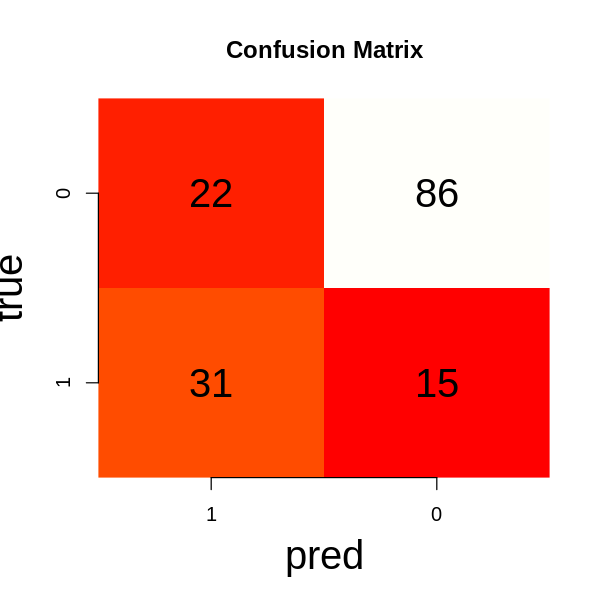

In [51]:
options(repr.plot.width=5, repr.plot.height=5)
m <- confusion_matrix
image(1:ncol(m), 1:nrow(m), t(m), col = heat.colors(100), axes = FALSE,
      xlab='pred', ylab='true', cex.lab=2, main='Confusion Matrix')
axis(1, 1:ncol(m), colnames(m))
axis(2, 1:nrow(m), rownames(m))
for (x in 1:2)
    for (y in 1:2)
        text(x, y, m[y,x], cex=2)

### 1. (f) Evaluation Statistics

Using the four values from the confusion matrix, we can construct evaulation statistics to get a numerical approximation for our model's performance. Spend some time researching accuracy, precision, recall and F score. 

Calculate these values for your model's predictions on the test set. Clearly display your results. How well do you think your model fits the data?

### Answer:

From the following definitions of the metrics, we can compute the scores as shown in the next code snippet:

$\begin{array}
\text{Accuracy} &=& \frac{TP+TN}{TP+FP+FN+TN} && \\
\text{Precision} &=& \frac{TP}{TP+FP} && \\
\text{Recall} &=& \frac{TP}{TP+FN} && \\
\text{F1}&=&2*\frac{\text{Precision \times Recall}}{\text{Precision + Recall}}&=& \frac{2\text{TP}}{2\text{TP + FP + FN}}
\end{array}$

In [54]:
# Your Code Here
accuracy <- (TP + TN) / (TP + FP + FN + TN)
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
f1score <- 2*precision*recall / (precision+recall)
data.frame('acc'=accuracy, 'prec'=precision, 'rec'=recall, 'f1'=f1score)

acc,prec,rec,f1
<dbl>,<dbl>,<dbl>,<dbl>
0.7597403,0.673913,0.5849057,0.6262626


According the above results, it seems the model fits the data quite well, with a decent accuracy, although recall value is a little low (indicating high number of false negatives).

### 1. (g) Understanding Evaluation Statistics

Answer the following questions in the markdown cell below.

1. Give an example scenario for when accuracy would be a misleading evaulation statistic.
2. Confusion matrices can also be used for non-binary classification problems. Describe what a confusion matrix would look like for a response with $3$ levels.
3. You'll have to take our word on the fact (or spend some time researching) that Type I error and Type II error are inversely related. That is, if a model is very good at detecting false positives, then it will be bad at detecting false negatives. In the case of our diabetes dataset, would you prefer a model that overestimates the Type 1 error or overestimates the Type II error. Justify your answer.

### Answer:

1. When we have very **imbalanced dataset**,  **accuracy** would be a misleading evaluation statistics. For example, let's say we want to test for a rare disease (with, e.g., $1\%$ of the population having the disease), then a binary classifier that predicts negative ($0$) all the time, will have $99\%$ accuarcy, but will be useless in finding the disease, **recall** will be a good metric in this case.
2. For a multiclass `n-class` classification problem ($n > 2$), the confusion matrix will be of size $n\times n$. The following code shows an example for $3$-class classification with the `iris` dataset, resulting in a $3\times 3$ confusion matrix.

In [72]:
library(nnet)
data(iris)
model.iris <- multinom(Species ~., data=iris, trace=F)
Species.pred <- predict(model.iris)
print('Confusion Matrix')
table(iris$Species, Species.pred)

[1] "Confusion Matrix"


            Species.pred
             setosa versicolor virginica
  setosa         50          0         0
  versicolor      0         49         1
  virginica       0          1        49

3. Since **FN** (false negatives) in this case will be more fatal (which implies a diabetes patient's disease remains undetected), the model should be more efficient in detecting them and should make **less type-II** errors (null hypothesis being that a patient does not have diabetes, we should be able to reject false null hypthesis as much as possible). 

Having **type-II** errors in this case implies more **FN** (false negatives), which would let diabetes go undetected and cause serious health problems. 

Having **Type-I** errors/**FP** (false positives) in this case implies predicting a positive diabetes test when diabetes isn't present. In such cases, individuals who were wrongly classified as diabetic can undergo further screening tests that would correct the issue. It will be better to have more **type-I** than having more **type-II** errors.

### 1. (h) Ethical Issues in Data Collection

Read Maya Iskandarani's [piece](https://researchblog.duke.edu/2016/10/24/diabetes-and-privacy-meet-big-data/) on consent and privacy concerns raised by this dataset. Summarize those concerns here.

### Answer:

Maya Iskandarani's piece discusses significant ethical concerns surrounding the Pima Indian Diabetes Data (PIDD) set, particularly in the context of **consent** and **data privacy** in medical research and data science.

* **Long-Term Consent Issues**: The research conducted on the Pima tribe began in 1965 and was intended to last 10 years but continued for about 40 years. The ethical problem arises from the fact that it's impossible to foresee how data collected today might be used decades later. This raises questions about the validity of the initial consent and whether it can be considered ongoing or "eternal."

* **Privacy Concerns**: The PIDD, which contains sensitive personal information like blood pressure, BMI, and pregnancy history of Pima Native Americans, has been publicly accessible for over 20 years. This raises serious privacy concerns, as the data is being used by researchers worldwide without the explicit consent of the individuals involved, potentially violating their right to privacy.

* **Ethical Use of Data in Machine Learning**: The PIDD has become a standard dataset for testing machine learning algorithms, yet the ethical implications of using such personal data without the subjects' current consent are troubling. While the dataset can advance scientific understanding and predictive modeling in diabetes, it also exemplifies the potential for exploitation and misuse of sensitive information.

These concerns highlight the complex ethical landscape in data science, where the benefits of research must be carefully weighed against the rights and autonomy of the individuals whose data is being used.

## Problem 2: Practicing those Math skills

One of the conditions of GLMs is that the "random component" of the data needs to come from the Exponential Family of Distributions. But how do we know if a distribution is in the Exponential Family? Well, we could look it up. Or we could be proper mathematicians and check the answer ourselves! Let's flex those math muscles.

### 2. (a) But it's in the name...

Show that $Y \sim exponential(\lambda)$, where $\lambda$ is known, is a member of the exponential family.

### Answer:

The pdf of an $Y$ is

$$\begin{array}
 ff(y;\lambda) &=& \lambda exp(-\lambda y) \\
             &=& exp(log \lambda -\lambda y) \\
             &=& exp\left(\frac{y \lambda - log \lambda}{-1} + 0\right) \\
             &=& exp\left(\frac{y \theta - b(\theta)}{a(\Phi)} + c(y, \Phi)\right)
\end{array}$$

where we have

$$\begin{array}
  \\\theta &=& \lambda && \\
  b(\theta) &=& b(\lambda) &=& log \lambda \\
  a(\Phi) &=& -1 && \\ 
  c(y, \Phi) &=& 0 &&
\end{array}$$

The above shows that it is a member of the exponential family.

Hence, we have 

$$\mu = E[Y] = b^{\prime}(\theta) = \frac{d\;log \lambda}{d\lambda} = \frac{1}{\lambda}$$
$$\sigma^2 = Var(Y) = b^{\prime\prime}(\theta)a(\Phi)=-\frac{1}{\lambda^2}.(-1) = \frac{1}{\lambda^2}$$

### 2. (b) Why can't plants do math? Because it gives them square roots!

Let $Y_i \sim exponential(\lambda)$ where $i \in \{ 1, \dots, n\}$. Then $Z = \sum_{i=1}^n Y_i \sim Gamma(n, \lambda)$. Show that $Z$ is also a member of the exponential family.

### Answer:

$Z \sim \Gamma(n, \lambda)$, hence pdf of $Z$ is

$f(z;\lambda,n) = \frac{\lambda^n}{\Gamma(n)}z^{n-1}e^{-\lambda z}=\frac{\lambda^n}{(n-1)!}z^{n-1}exp(-\lambda z)$

$$\begin{array}
 ff(y;\lambda, n) &=& \frac{\lambda^n}{(n-1)!}z^{n-1}e^{-\lambda z} \\
             &=& exp\left(n log\lambda-log (n-1)!\right).exp\left((n-1)log z\right).exp\left(-\lambda z\right) \\
             &=& exp\left(n log\lambda-\lambda z +(n-1)log(z) - log (n-1)! \right) \\
             &=& exp\left(\frac{z \lambda - n log \lambda}{-1} + (n-1)log z - log (n-1)! \right) \\
             &=& exp\left(\frac{z \theta - b(\theta)}{a(\Phi)} + c(z, \Phi)\right)
\end{array}$$

where we have

$$\begin{array}
  \\\theta &=& \lambda && \\
  b(\theta) &=& b(\lambda) &=& n log\lambda \\
  \Phi &=& n && \\ 
  a(\Phi) &=& a(n) &=& -1 \\ 
  c(z, \Phi) &=& c(z, n) &=& (n-1)log z - log (n-1)!
\end{array}$$

The above shows that it is a member of the exponential family.

Hence, we have 

$$\mu = E[Y] = b^{\prime}(\lambda) = \frac{d\;n log\lambda}{d\lambda} = \frac{n}{\lambda}$$
$$\sigma^2 = Var(Y) = b^{\prime\prime}(\lambda)a(n)=-\frac{n}{\lambda^2}.(-1) = \frac{n}{\lambda^2}$$